# Figure 4 v5 — OF and VR Baseline pR² (5 × 2 layout)

In [198]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats
import os, glob, warnings
warnings.filterwarnings('ignore')
%matplotlib inline

plt.rcParams['font.family'] = 'Arial'

CI_FAC = 1.96
MAX_N  = 10

out_dir = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_xgboost/'
os.makedirs(out_dir, exist_ok=True)

In [199]:
MIN_BYTES = 100

def _load_assay_csvs(src):
    files = glob.glob(os.path.join(src, '*.csv'))
    valid_files, skipped = [], []
    for f in files:
        size = os.path.getsize(f)
        if size < MIN_BYTES:
            skipped.append((f, size))
        else:
            valid_files.append(f)
    for f, size in skipped:
        print(f'Skipped ({size} byte{"s" if size != 1 else ""}): {os.path.basename(f)}')
    if skipped:
        print(f'  {len(skipped)} file(s) skipped, {len(valid_files)} loading...')
    df = pd.concat(
        [pd.read_csv(f, keep_default_na=False, na_values=['']) for f in valid_files],
        ignore_index=True
    )
    df = df.dropna(how='all')
    df['baseline'] = df['baseline'].replace('pos_speed_hd_hing_lfp', 'pos_speed_hd_lfp')
    df = df[~df['baseline'].str.contains('hing', na=False)]
    if 'n_neurons' in df.columns and 'n_covariate_cells' not in df.columns:
        df = df.rename(columns={'n_neurons': 'n_covariate_cells', 'pR2': 'pR2_cv'})
    return df

print('Loading VR data...')
data_vr = _load_assay_csvs('/Users/harryclark/Documents/spatial-manifolds/data/eddie/xgboost_cell_number_assay/')
print(f'VR:  {data_vr.shape}  baselines: {sorted(data_vr["baseline"].dropna().unique())}\n')

print('Loading OF data...')
data_of = _load_assay_csvs('/Users/harryclark/Documents/spatial-manifolds/data/eddie/xgboost_cell_number_assay_of/')
print(f'OF:  {data_of.shape}  baselines: {sorted(data_of["baseline"].dropna().unique())}')

Loading VR data...
Skipped (1 byte): xgboost_cell_number_assay_extra_M20_D25_h30_40_50.csv
Skipped (1 byte): xgboost_cell_number_assay_extra_M21_D24_h30_160_166.csv
Skipped (1 byte): xgboost_cell_number_assay_extra_M21_D26_h30_170_179.csv
Skipped (1 byte): xgboost_cell_number_assay_extra_M21_D21_h30_240_250.csv
Skipped (1 byte): xgboost_cell_number_assay_extra_M25_D25_h30_120_130.csv
Skipped (1 byte): xgboost_cell_number_assay_extra_M20_D24_h30_80_81.csv
Skipped (1 byte): xgboost_cell_number_assay_extra_M21_D22_h30_140_146.csv
Skipped (1 byte): xgboost_cell_number_assay_extra_M21_D21_h30_220_230.csv
Skipped (1 byte): xgboost_cell_number_assay_extra_M25_D25_h30_140_150.csv
Skipped (1 byte): xgboost_cell_number_assay_extra_M20_D25_h100_50_51.csv
Skipped (1 byte): xgboost_cell_number_assay_extra_M25_D18_h30_140_146.csv
Skipped (1 byte): xgboost_cell_number_assay_extra_M25_D25_h30_150_152.csv
Skipped (1 byte): xgboost_cell_number_assay_extra_M20_D25_h30_50_51.csv
Skipped (1 byte): xgboost_

In [200]:
def infer_target_type(cov_set):
    if 'cmGC'  in cov_set: return 'cmGC'
    if 'ncmGC' in cov_set: return 'ncmGC'
    return 'NGS'

def _add_target_broad(df):
    tt = (df.groupby(['mouse', 'day', 'target_cluster_id'])['covariate_type']
            .apply(lambda x: infer_target_type(set(x)))
            .reset_index()
            .rename(columns={'covariate_type': 'target_type'}))
    df = df.merge(tt, on=['mouse', 'day', 'target_cluster_id'], how='left')
    df['target_broad'] = df['target_type'].apply(
        lambda t: 'GC' if t in ('cmGC', 'ncmGC') else 'NGS')
    return df

def sig_star(p):
    if pd.isna(p): return ''
    if p < 0.001:  return '***'
    if p < 0.01:   return '**'
    if p < 0.05:   return '*'
    return 'ns'

data_vr = _add_target_broad(data_vr)
data_of = _add_target_broad(data_of)

cov_col = 'covariate_cell_type'
print('VR target types:', data_vr['target_broad'].value_counts().to_dict())
print('OF target types:', data_of['target_broad'].value_counts().to_dict())
print('\nVR covariate types:', sorted(data_vr[cov_col].dropna().unique()))
print('OF covariate types:', sorted(data_of[cov_col].dropna().unique()))

VR target types: {'NGS': 1217356, 'GC': 81468}
OF target types: {'NGS': 4197063, 'GC': 361030}

VR covariate types: ['GC', 'NGS']
OF covariate types: ['GC', 'NGS']


In [201]:
# target × covariate combination palette
# GC targets first, GC covariates first within each target group
# GC target family: reds  |  NGS target family: blues
# GC covariates: darker   |  NGS covariates: brighter
COMBO_DEFS = [
    ('GC',  'GC',  '#8B2500', 'GC target\nGC cov'),
    ('GC',  'NGS', '#c04744', 'GC target\nNGS cov'),
    ('NGS', 'GC',  '#1a4971', 'NGS target\nGC cov'),
    ('NGS', 'NGS', '#3171ae', 'NGS target\nNGS cov'),
]

TICK_FS = 7   # uniform tick-label fontsize across all panels

def _make_figure(data, baseline_order, baseline_label, title_prefix, save_name):
    """6-column x 2-row layout (col 1 is a blank spacer).
    Row 1: [baseline bars] [sp] [GC+GC] [GC+NGS] [NGS+GC] [NGS+NGS]
    Row 2: [Δ pR² errorbar] [sp] [violin spanning cols 3-5] [ ] [ ]
    """
    n_bl   = len(baseline_order)
    x      = np.arange(n_bl)
    xl     = [baseline_label[b] for b in baseline_order]
    err_kw = dict(elinewidth=1, capsize=3, ecolor='#333')

    avail_cov   = sorted(data[cov_col].dropna().unique())
    combos      = [(t, c, col, lbl) for t, c, col, lbl in COMBO_DEFS if c in avail_cov]
    line_combos = combos[:4]

    print(f'Covariate types in data: {avail_cov}')
    print(f'Active combinations:     {[lbl for *_, lbl in combos]}')

    # 6 columns: 0=main, 1=spacer, 2-5=line plots (consecutive, no gap)
    fig = plt.figure(figsize=(10, 6))   # A4 landscape-safe
    gs  = fig.add_gridspec(2, 6,
                           width_ratios=[2.6, 0.15, 0.6, 0.6, 0.6, 0.6],
                           wspace=0.18, hspace=0.3)

    ax_bl  = fig.add_subplot(gs[0, 0])
    lp_axs = [fig.add_subplot(gs[0, k + 2]) for k in range(len(line_combos))]
    ax_dlt = fig.add_subplot(gs[1, 0])
    ax_vln = fig.add_subplot(gs[1, 3:6])

    # ── Row 1, Col 1: Kinematic baseline pR2 (n=0) ────────────────────
    n0 = (data[data['n_covariate_cells'] == 0]
               .drop_duplicates(subset=['mouse', 'day', 'target_cluster_id', 'baseline']))
    gc_bl  = (n0[n0['target_broad'] == 'GC'].groupby('baseline')['pR2_cv']
                .agg(mean='mean', sem=lambda z: z.sem()).reindex(baseline_order))
    ngs_bl = (n0[n0['target_broad'] == 'NGS'].groupby('baseline')['pR2_cv']
                .agg(mean='mean', sem=lambda z: z.sem()).reindex(baseline_order))

    ax_bl.bar(x - 0.2, gc_bl['mean'],  yerr=CI_FAC * gc_bl['sem'],
              width=0.38, color='#c04744', alpha=0.82, edgecolor='#333', linewidth=0.5,
              error_kw=err_kw, label='GC target')
    ax_bl.bar(x + 0.2, ngs_bl['mean'], yerr=CI_FAC * ngs_bl['sem'],
              width=0.38, color='#3171ae', alpha=0.82, edgecolor='#333', linewidth=0.5,
              error_kw=err_kw, label='NGS target')
    for xi, bl in enumerate(baseline_order):
        gc_v  = n0[(n0['target_broad'] == 'GC')  & (n0['baseline'] == bl)]['pR2_cv'].dropna()
        ngs_v = n0[(n0['target_broad'] == 'NGS') & (n0['baseline'] == bl)]['pR2_cv'].dropna()
        if len(gc_v) < 3 or len(ngs_v) < 3: continue
        p    = sp_stats.mannwhitneyu(gc_v, ngs_v, alternative='two-sided').pvalue
        star = sig_star(p)
        if not star: continue
        y_top = max(gc_bl.loc[bl, 'mean'] + CI_FAC * gc_bl.loc[bl, 'sem'],
                    ngs_bl.loc[bl, 'mean'] + CI_FAC * ngs_bl.loc[bl, 'sem']) + 0.003
        ax_bl.plot([xi - 0.2, xi + 0.2], [y_top, y_top], color='k', lw=0.8)
        ax_bl.text(xi, y_top + 0.001, star, ha='center', va='bottom', fontsize=TICK_FS)
    ax_bl.axhline(0, color='k', lw=0.7, ls='--', alpha=0.4)
    ax_bl.set_xticks(x)
    ax_bl.set_xticklabels(xl, rotation=40, ha='right', fontsize=TICK_FS)
    ax_bl.tick_params(labelsize=TICK_FS)
    ax_bl.set_ylabel('Baseline pR²  (mean ± 95% CI)', fontsize=9)
    ax_bl.legend(fontsize=TICK_FS, frameon=False)
    ax_bl.spines[['top', 'right']].set_visible(False)

    # ── Row 1, Cols 2-5: pR² − n=0 value vs n covariate cells ────────
    BL_CMAP = dict(zip(baseline_order,
                       plt.cm.inferno(np.linspace(0.1, 0.85, n_bl))))

    def _draw_lines(ax, target_broad, cov_type, title_color, title):
        sub = data[
            (data['target_broad'] == target_broad) &
            (data[cov_col]        == cov_type) &
            (data['baseline'].isin(baseline_order))
        ]
        lp = (sub[sub['n_covariate_cells'].between(0, MAX_N)]
              .groupby(['baseline', 'n_covariate_cells'])['pR2_cv']
              .agg(mean='mean', sem=lambda z: z.sem())
              .reset_index())
        for bl in baseline_order:
            s = lp[lp['baseline'] == bl].sort_values('n_covariate_cells')
            if s.empty: continue
            n0_rows = s[s['n_covariate_cells'] == 0]['mean'].values
            if len(n0_rows) == 0: continue
            offset = n0_rows[0]
            c = BL_CMAP[bl]
            ax.plot(s['n_covariate_cells'], s['mean'] - offset, color=c, lw=1.8,
                    label=baseline_label[bl])
            ax.fill_between(s['n_covariate_cells'],
                            s['mean'] - s['sem'] - offset,
                            s['mean'] + s['sem'] - offset,
                            color=c, alpha=0.15)
        ax.set_xlim(0, MAX_N); ax.set_xticks([0, 5, 10])
        ax.set_xlabel('n covariate cells', fontsize=9)
        ax.set_ylabel('Δ pR² from n=0', fontsize=9)
        ax.set_title(title, fontsize=9, color=title_color, fontweight='bold')
        ax.axhline(0, color='#ccc', lw=0.6, ls=':')
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=TICK_FS)

    for k, (tgt, cov, col, lbl) in enumerate(line_combos):
        _draw_lines(lp_axs[k], tgt, cov, col, lbl)
    for ax in lp_axs[1:]:
        ax.set_ylabel(''); ax.set_yticklabels([])

    # Baseline legend to the right of last line plot panel
    lp_axs[-1].legend(fontsize=6, frameon=False,
                      bbox_to_anchor=(1.03, 1), loc='upper left',
                      title='Baseline', title_fontsize=TICK_FS,
                      borderaxespad=0)

    # Shared ylim across line plots only (ax_bl is on a different scale)
    _ymin = min(a.get_ylim()[0] for a in lp_axs)
    _ymax = max(a.get_ylim()[1] for a in lp_axs)
    for a in lp_axs:
        a.set_ylim(_ymin, _ymax)

    # ── Delta pR² helper ───────────────────────────────────────────────
    def _delta(target_broad, cov_type):
        sub = data[
            (data['target_broad'] == target_broad) &
            (data[cov_col]        == cov_type) &
            (data['baseline'].isin(baseline_order))
        ]
        uid   = ['mouse', 'day', 'target_cluster_id', 'baseline']
        pivot = sub.pivot_table(index=uid, columns='n_covariate_cells', values='pR2_cv')
        pivot.columns = pivot.columns.astype(int)
        if 0 not in pivot.columns or MAX_N not in pivot.columns:
            return pd.DataFrame()
        valid          = pivot.dropna(subset=[0, MAX_N]).reset_index()
        valid['delta'] = valid[MAX_N] - valid[0]
        return valid

    dlt_cache = {}
    for tgt, cov, col, lbl in combos:
        dlt_cache[(tgt, cov)] = _delta(tgt, cov)

    # ── Row 2, Col 0: Δ pR² connected errorbars ───────────────────────
    n_combos = len(combos)
    for ci, (tgt, cov, col, lbl) in enumerate(combos):
        dlt = dlt_cache[(tgt, cov)]
        if dlt.empty: continue
        agg   = (dlt.groupby('baseline')['delta']
                    .agg(mean='mean', sem=lambda z: z.sem())
                    .reindex(baseline_order))
        x_off = x + (ci - (n_combos - 1) / 2) * 0.15
        ax_dlt.errorbar(x_off, agg['mean'], yerr=CI_FAC * agg['sem'],
                        color=col, fmt='o-', markersize=5, linewidth=1.8,
                        capsize=4, capthick=1.2, label=lbl)

    ax_dlt.axhline(0, color='k', lw=0.7, ls='--', alpha=0.4)
    ax_dlt.set_xticks(x)
    ax_dlt.set_xticklabels(xl, rotation=40, ha='right', fontsize=TICK_FS)
    ax_dlt.tick_params(labelsize=TICK_FS)
    ax_dlt.set_ylabel(f'Δ pR²  (n={MAX_N} cells − baseline only)', fontsize=9)
    ax_dlt.legend(fontsize=TICK_FS, frameon=False, loc='lower left')
    ax_dlt.spines[['top', 'right']].set_visible(False)

    # ── Row 2, Cols 3-5: Violin — Δ pR²(null) − Δ pR²(complex) ───────
    null_bl = baseline_order[0]
    max_bl  = baseline_order[-1]
    uid     = ['mouse', 'day', 'target_cluster_id']
    VW      = 0.55
    vln_x   = [0, 1, 2.3, 3.3]

    def _diff_vals(tgt, cov):
        """Per-cell Δ pR²(null) − Δ pR²(complex): positive = redundancy."""
        dlt = dlt_cache[(tgt, cov)]
        if dlt.empty: return np.array([])
        d_null = dlt[dlt['baseline'] == null_bl].set_index(uid)['delta']
        d_max  = dlt[dlt['baseline'] == max_bl ].set_index(uid)['delta']
        paired = pd.concat([d_null, d_max], axis=1, keys=['null', 'max']).dropna()
        return (paired['null'] - paired['max']).values

    diff_data = [_diff_vals(tgt, cov) for tgt, cov, *_ in combos]

    _all_d  = np.concatenate([v for v in diff_data if len(v)])
    _yd_min = np.nanpercentile(_all_d, 1)  if len(_all_d) else -0.05
    _yd_max = np.nanpercentile(_all_d, 99) if len(_all_d) else  0.05
    vstep   = max((_yd_max - _yd_min) * 0.05, 0.003)
    y_annot_base = _yd_min - vstep * 1.2

    vln_top = {}
    for ci, ((tgt, cov, col, lbl), vals) in enumerate(zip(combos, diff_data)):
        xv = vln_x[ci]
        vln_top[ci] = np.nanpercentile(vals, 99) if len(vals) > 1 else _yd_max
        if len(vals) < 3: continue
        vp = ax_vln.violinplot(vals, positions=[xv], widths=VW,
                               showmeans=False, showmedians=True, showextrema=False)
        vp['cmedians'].set_color('k')
        vp['cmedians'].set_linewidth(1.8)
        for body in vp['bodies']:
            body.set_facecolor(col)
            body.set_edgecolor('k')
            body.set_linewidth(0.7)
            body.set_alpha(0.85)

    for ci, ((tgt, cov, col, lbl), vals) in enumerate(zip(combos, diff_data)):
        if len(vals) < 5: continue
        _, p = sp_stats.wilcoxon(vals)
        ax_vln.text(vln_x[ci], y_annot_base, sig_star(p) or 'ns',
                    ha='center', va='top', fontsize=TICK_FS, color='#333')

    bg_base  = max(vln_top.values(), default=_yd_max) + vstep * 0.8
    bg_pairs = [(0, 1, 0), (2, 3, 0), (0, 2, 1), (1, 3, 2)]
    for i, j, lvl in bg_pairs:
        if i >= len(diff_data) or j >= len(diff_data): continue
        vi, vj = diff_data[i], diff_data[j]
        if len(vi) < 3 or len(vj) < 3: continue
        _, p = sp_stats.mannwhitneyu(vi, vj, alternative='two-sided')
        yb   = bg_base + lvl * vstep * 1.8
        xi, xj = vln_x[i], vln_x[j]
        ax_vln.plot([xi, xi, xj, xj], [yb, yb+vstep*0.3, yb+vstep*0.3, yb],
                    color='#444', lw=0.8)
        ax_vln.text((xi+xj)/2, yb+vstep*0.4, sig_star(p) or 'ns',
                    ha='center', va='bottom', fontsize=6)

    ax_vln.axhline(0, color='k', lw=0.7, ls='--', alpha=0.4)
    ax_vln.set_xticks(vln_x[:len(combos)])
    ax_vln.set_xticklabels([lbl for *_, lbl in combos], fontsize=TICK_FS)
    ax_vln.tick_params(labelsize=TICK_FS)
    ax_vln.set_ylabel(f'Δ pR²(null) − Δ pR²(complex)\n(n={MAX_N} cells)', fontsize=9)
    ax_vln.set_ylim(y_annot_base - vstep * 1.5,
                    bg_base + 3 * vstep * 1.8 + vstep)
    ax_vln.spines[['top', 'right']].set_visible(False)

    fig.savefig(os.path.join(out_dir, save_name), bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved: {save_name}')

In [202]:
def _make_figure_1row(data, baseline_order, baseline_label, title_prefix, save_name):
    """Single-row layout: [baseline bars] [sp] [GC+GC] [GC+NGS] [NGS+GC] [NGS+NGS] [violin].
    No Δ pR² errorbar panel — violin goes to the right of the line plots.
    """
    n_bl   = len(baseline_order)
    x      = np.arange(n_bl)
    xl     = [baseline_label[b] for b in baseline_order]
    err_kw = dict(elinewidth=1, capsize=3, ecolor='#333')

    avail_cov   = sorted(data[cov_col].dropna().unique())
    combos      = [(t, c, col, lbl) for t, c, col, lbl in COMBO_DEFS if c in avail_cov]
    line_combos = combos[:4]

    # 7 columns: 0=bars, 1=spacer, 2-5=line plots, 6=violin
    fig = plt.figure(figsize=(10, 2.5))   # A4 landscape-safe, half-page height
    gs  = fig.add_gridspec(1, 7,
                           width_ratios=[2.6, 0.15, 0.6, 0.6, 0.6, 0.6, 1.4],
                           wspace=0.18)

    ax_bl  = fig.add_subplot(gs[0, 0])
    lp_axs = [fig.add_subplot(gs[0, k + 2]) for k in range(len(line_combos))]
    ax_vln = fig.add_subplot(gs[0, 6])

    # ── Col 0: Kinematic baseline pR2 (n=0) ───────────────────────────
    n0 = (data[data['n_covariate_cells'] == 0]
               .drop_duplicates(subset=['mouse', 'day', 'target_cluster_id', 'baseline']))
    gc_bl  = (n0[n0['target_broad'] == 'GC'].groupby('baseline')['pR2_cv']
                .agg(mean='mean', sem=lambda z: z.sem()).reindex(baseline_order))
    ngs_bl = (n0[n0['target_broad'] == 'NGS'].groupby('baseline')['pR2_cv']
                .agg(mean='mean', sem=lambda z: z.sem()).reindex(baseline_order))

    ax_bl.bar(x - 0.2, gc_bl['mean'],  yerr=CI_FAC * gc_bl['sem'],
              width=0.38, color='#c04744', alpha=0.82, edgecolor='#333', linewidth=0.5,
              error_kw=err_kw, label='GC target')
    ax_bl.bar(x + 0.2, ngs_bl['mean'], yerr=CI_FAC * ngs_bl['sem'],
              width=0.38, color='#3171ae', alpha=0.82, edgecolor='#333', linewidth=0.5,
              error_kw=err_kw, label='NGS target')
    for xi, bl in enumerate(baseline_order):
        gc_v  = n0[(n0['target_broad'] == 'GC')  & (n0['baseline'] == bl)]['pR2_cv'].dropna()
        ngs_v = n0[(n0['target_broad'] == 'NGS') & (n0['baseline'] == bl)]['pR2_cv'].dropna()
        if len(gc_v) < 3 or len(ngs_v) < 3: continue
        p    = sp_stats.mannwhitneyu(gc_v, ngs_v, alternative='two-sided').pvalue
        star = sig_star(p)
        if not star: continue
        y_top = max(gc_bl.loc[bl, 'mean'] + CI_FAC * gc_bl.loc[bl, 'sem'],
                    ngs_bl.loc[bl, 'mean'] + CI_FAC * ngs_bl.loc[bl, 'sem']) + 0.003
        ax_bl.plot([xi - 0.2, xi + 0.2], [y_top, y_top], color='k', lw=0.8)
        ax_bl.text(xi, y_top + 0.001, star, ha='center', va='bottom', fontsize=TICK_FS)
    ax_bl.axhline(0, color='k', lw=0.7, ls='--', alpha=0.4)
    ax_bl.set_xticks(x)
    ax_bl.set_xticklabels(xl, rotation=40, ha='right', fontsize=TICK_FS)
    ax_bl.tick_params(labelsize=TICK_FS)
    ax_bl.set_ylabel('Baseline pR²  (mean ± 95% CI)', fontsize=9)
    ax_bl.legend(fontsize=TICK_FS, frameon=False)
    ax_bl.spines[['top', 'right']].set_visible(False)

    # ── Cols 2-5: pR² − n=0 vs n covariate cells ──────────────────────
    BL_CMAP = dict(zip(baseline_order,
                       plt.cm.inferno(np.linspace(0.1, 0.85, n_bl))))

    def _draw_lines(ax, target_broad, cov_type, title_color, title):
        sub = data[
            (data['target_broad'] == target_broad) &
            (data[cov_col]        == cov_type) &
            (data['baseline'].isin(baseline_order))
        ]
        lp = (sub[sub['n_covariate_cells'].between(0, MAX_N)]
              .groupby(['baseline', 'n_covariate_cells'])['pR2_cv']
              .agg(mean='mean', sem=lambda z: z.sem())
              .reset_index())
        for bl in baseline_order:
            s = lp[lp['baseline'] == bl].sort_values('n_covariate_cells')
            if s.empty: continue
            n0_rows = s[s['n_covariate_cells'] == 0]['mean'].values
            if len(n0_rows) == 0: continue
            offset = n0_rows[0]
            c = BL_CMAP[bl]
            ax.plot(s['n_covariate_cells'], s['mean'] - offset, color=c, lw=1.8,
                    label=baseline_label[bl])
            ax.fill_between(s['n_covariate_cells'],
                            s['mean'] - s['sem'] - offset,
                            s['mean'] + s['sem'] - offset,
                            color=c, alpha=0.15)
        ax.set_xlim(0, MAX_N); ax.set_xticks([0, 5, 10])
        ax.set_xlabel('n covariate cells', fontsize=9)
        ax.set_ylabel('Δ pR² from n=0', fontsize=9)
        ax.set_title(title, fontsize=9, color=title_color, fontweight='bold')
        ax.axhline(0, color='#ccc', lw=0.6, ls=':')
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=TICK_FS)

    for k, (tgt, cov, col, lbl) in enumerate(line_combos):
        _draw_lines(lp_axs[k], tgt, cov, col, lbl)
    for ax in lp_axs[1:]:
        ax.set_ylabel(''); ax.set_yticklabels([])

    # Baseline legend to the right of the last line plot
    lp_axs[-1].legend(fontsize=6, frameon=False,
                      bbox_to_anchor=(1.03, 1), loc='upper left',
                      title='Baseline', title_fontsize=TICK_FS,
                      borderaxespad=0)

    # Shared ylim across line plots
    _ymin = min(a.get_ylim()[0] for a in lp_axs)
    _ymax = max(a.get_ylim()[1] for a in lp_axs)
    for a in lp_axs:
        a.set_ylim(_ymin, _ymax)

    # ── Delta pR² helper ───────────────────────────────────────────────
    def _delta(target_broad, cov_type):
        sub = data[
            (data['target_broad'] == target_broad) &
            (data[cov_col]        == cov_type) &
            (data['baseline'].isin(baseline_order))
        ]
        uid   = ['mouse', 'day', 'target_cluster_id', 'baseline']
        pivot = sub.pivot_table(index=uid, columns='n_covariate_cells', values='pR2_cv')
        pivot.columns = pivot.columns.astype(int)
        if 0 not in pivot.columns or MAX_N not in pivot.columns:
            return pd.DataFrame()
        valid          = pivot.dropna(subset=[0, MAX_N]).reset_index()
        valid['delta'] = valid[MAX_N] - valid[0]
        return valid

    dlt_cache = {}
    for tgt, cov, col, lbl in combos:
        dlt_cache[(tgt, cov)] = _delta(tgt, cov)

    # ── Col 6: Violin — Δ pR²(null) − Δ pR²(complex) ─────────────────
    null_bl = baseline_order[0]
    max_bl  = baseline_order[-1]
    uid     = ['mouse', 'day', 'target_cluster_id']
    VW      = 0.55
    vln_x   = [0, 1, 2.3, 3.3]

    def _diff_vals(tgt, cov):
        dlt = dlt_cache[(tgt, cov)]
        if dlt.empty: return np.array([])
        d_null = dlt[dlt['baseline'] == null_bl].set_index(uid)['delta']
        d_max  = dlt[dlt['baseline'] == max_bl ].set_index(uid)['delta']
        paired = pd.concat([d_null, d_max], axis=1, keys=['null', 'max']).dropna()
        return (paired['null'] - paired['max']).values

    diff_data = [_diff_vals(tgt, cov) for tgt, cov, *_ in combos]

    _all_d  = np.concatenate([v for v in diff_data if len(v)])
    _yd_min = np.nanpercentile(_all_d, 1)  if len(_all_d) else -0.05
    _yd_max = np.nanpercentile(_all_d, 99) if len(_all_d) else  0.05
    vstep   = max((_yd_max - _yd_min) * 0.05, 0.003)
    y_annot_base = _yd_min - vstep * 1.2

    vln_top = {}
    for ci, ((tgt, cov, col, lbl), vals) in enumerate(zip(combos, diff_data)):
        xv = vln_x[ci]
        vln_top[ci] = np.nanpercentile(vals, 99) if len(vals) > 1 else _yd_max
        if len(vals) < 3: continue
        vp = ax_vln.violinplot(vals, positions=[xv], widths=VW,
                               showmeans=False, showmedians=True, showextrema=False)
        vp['cmedians'].set_color('k')
        vp['cmedians'].set_linewidth(1.8)
        for body in vp['bodies']:
            body.set_facecolor(col)
            body.set_edgecolor('k')
            body.set_linewidth(0.7)
            body.set_alpha(0.85)

    for ci, ((tgt, cov, col, lbl), vals) in enumerate(zip(combos, diff_data)):
        if len(vals) < 5: continue
        _, p = sp_stats.wilcoxon(vals)
        ax_vln.text(vln_x[ci], y_annot_base, sig_star(p) or 'ns',
                    ha='center', va='top', fontsize=TICK_FS, color='#333')

    bg_base  = max(vln_top.values(), default=_yd_max) + vstep * 0.8
    bg_pairs = [(0, 1, 0), (2, 3, 0), (0, 2, 1), (1, 3, 2)]
    for i, j, lvl in bg_pairs:
        if i >= len(diff_data) or j >= len(diff_data): continue
        vi, vj = diff_data[i], diff_data[j]
        if len(vi) < 3 or len(vj) < 3: continue
        _, p = sp_stats.mannwhitneyu(vi, vj, alternative='two-sided')
        yb   = bg_base + lvl * vstep * 1.8
        xi, xj = vln_x[i], vln_x[j]
        ax_vln.plot([xi, xi, xj, xj], [yb, yb+vstep*0.3, yb+vstep*0.3, yb],
                    color='#444', lw=0.8)
        ax_vln.text((xi+xj)/2, yb+vstep*0.4, sig_star(p) or 'ns',
                    ha='center', va='bottom', fontsize=6)

    ax_vln.axhline(0, color='k', lw=0.7, ls='--', alpha=0.4)
    ax_vln.set_xticks(vln_x[:len(combos)])
    ax_vln.set_xticklabels([lbl for *_, lbl in combos], fontsize=TICK_FS)
    ax_vln.tick_params(labelsize=TICK_FS)
    ax_vln.set_ylabel(f'Δ pR²(null) − Δ pR²(complex)\n(n={MAX_N} cells)', fontsize=9)
    ax_vln.set_ylim(y_annot_base - vstep * 1.5,
                    bg_base + 3 * vstep * 1.8 + vstep)
    ax_vln.spines[['top', 'right']].set_visible(False)

    fig.savefig(os.path.join(out_dir, save_name), bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved: {save_name}')

## Open Field

### What this figure measures

Each cell's spiking is modelled by an XGBoost regression fitted to a **kinematic baseline** (combinations of position, speed, head direction, LFP theta). Cross-validated pseudo-R² (pR²) quantifies how well kinematics alone account for firing.

To test whether **population activity** carries additional information beyond kinematics, we add *n* covariate cells' spike rates as extra features and track how pR² grows.

| Row | Panel | Content |
|-----|-------|---------|
| 1 | Col 1 | Kinematic baseline pR² (n=0 covariate cells) for GC vs NGS target cells. Two bars per baseline; stars = Mann–Whitney GC vs NGS. |
| 1 | Cols 2-4 | pR² vs n covariate cells added (0–10), one trace per baseline, for up to three target × covariate type combinations. Colours encode baseline complexity (viridis). |
| 2 | Col 1 | Δ pR² = pR²(+10 cells) − pR²(baseline only), all target × covariate combinations shown together with 95% CI errorbars and small x-jitter for legibility. |

---

### Suggested plots for row 2, cols 2-5

**Col 2 — Per-mouse Δ pR² (reproducibility check)**  
Grouped errorbar with one point per mouse per combination. Checks whether the population signal is consistent across animals or dominated by a single session.

**Col 3 — Ceiling effect: Δ pR² vs kinematic baseline pR² scatter**  
Per-cell scatter, x = baseline pR², y = Δ pR². Tests whether cells already well explained by kinematics gain less from population covariates. Colour by target type.

**Col 4 — Dose-response: fraction of cells exceeding a Δ pR² threshold vs n covariate cells**  
For a fixed threshold (e.g., Δ pR² > 0.01), plot the fraction of target cells that pass vs n (0–10), one curve per combination. Shows diminishing returns and the minimum n needed.

**Col 5 — Selectivity: NGS covariate Δ pR² vs GC covariate Δ pR² (if both available)**  
One point per GC target cell: x = Δ pR² from adding NGS covariates, y = Δ pR² from adding GC covariates. Points on the diagonal = equivalent contribution; off-diagonal = preferential contribution from one population type.

Covariate types in data: ['GC', 'NGS']
Active combinations:     ['GC target\nGC cov', 'GC target\nNGS cov', 'NGS target\nGC cov', 'NGS target\nNGS cov']


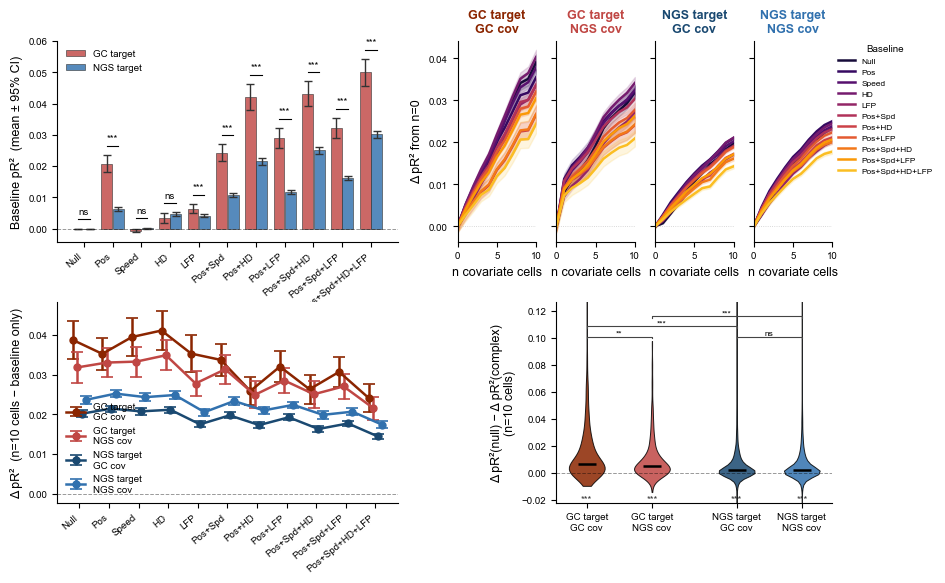

Saved: Figure4_v5_OF_baselines.pdf


In [203]:
OF_BASELINE_ORDER = [
    'null',
    'pos', 'speed', 'hd', 'lfp',
    'pos_speed', 'pos_hd', 'pos_lfp',
    'pos_speed_hd', 'pos_speed_lfp',
    'pos_speed_hd_lfp',
]
OF_BASELINE_LABEL = {
    'null':             'Null',
    'pos':              'Pos',
    'speed':            'Speed',
    'hd':               'HD',
    'lfp':              'LFP',
    'pos_speed':        'Pos+Spd',
    'pos_hd':           'Pos+HD',
    'pos_lfp':          'Pos+LFP',
    'pos_speed_hd':     'Pos+Spd+HD',
    'pos_speed_lfp':    'Pos+Spd+LFP',
    'pos_speed_hd_lfp': 'Pos+Spd+HD+LFP',
}

_make_figure(data_of, OF_BASELINE_ORDER, OF_BASELINE_LABEL,
             'OF', 'Figure4_v5_OF_baselines.pdf')

## Virtual Reality

Same 5 × 2 panel layout as the OF section. VR has no head-direction signal, so the most complex baseline is `pos_speed_lfp`. The interpretation of every panel is otherwise identical.

Covariate types in data: ['GC', 'NGS']
Active combinations:     ['GC target\nGC cov', 'GC target\nNGS cov', 'NGS target\nGC cov', 'NGS target\nNGS cov']


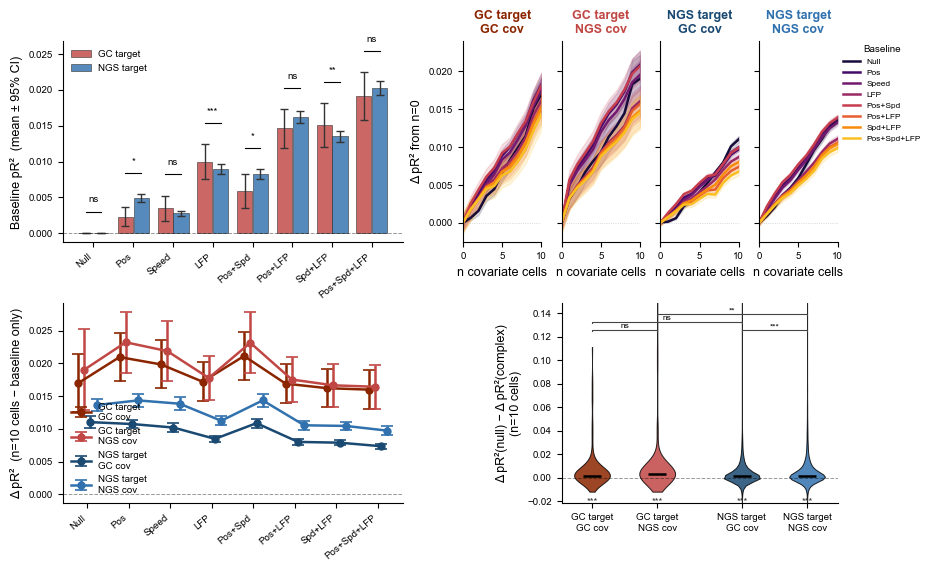

Saved: Figure4_v5_VR_baselines.pdf


In [204]:
VR_BASELINE_ORDER = [
    'null',
    'pos', 'speed', 'lfp',
    'pos_speed', 'pos_lfp', 'speed_lfp',
    'pos_speed_lfp',
]
VR_BASELINE_LABEL = {
    'null':          'Null',
    'pos':           'Pos',
    'speed':         'Speed',
    'lfp':           'LFP',
    'pos_speed':     'Pos+Spd',
    'pos_lfp':       'Pos+LFP',
    'speed_lfp':     'Spd+LFP',
    'pos_speed_lfp': 'Pos+Spd+LFP',
}

_make_figure(data_vr, VR_BASELINE_ORDER, VR_BASELINE_LABEL,
             'VR', 'Figure4_v5_VR_baselines.pdf')

## Single-row alternative

Same panels as above but collapsed to one row — the Δ pR² errorbar panel is removed and the violin moves to the far right.

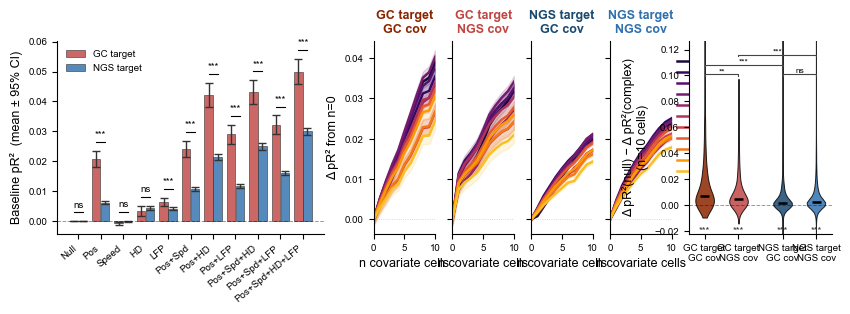

Saved: Figure4_v5_OF_1row.pdf


In [205]:
_make_figure_1row(data_of, OF_BASELINE_ORDER, OF_BASELINE_LABEL,
                  'OF', 'Figure4_v5_OF_1row.pdf')

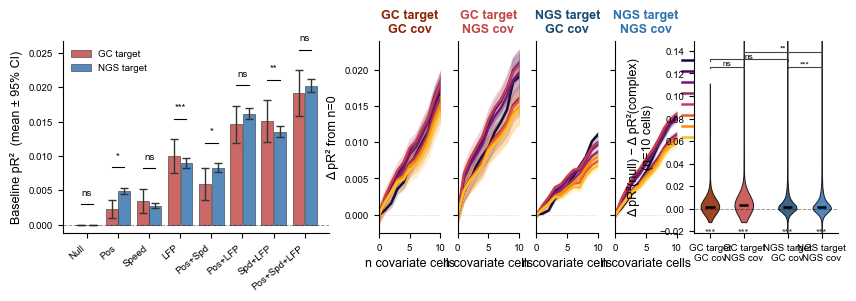

Saved: Figure4_v5_VR_1row.pdf


In [206]:
_make_figure_1row(data_vr, VR_BASELINE_ORDER, VR_BASELINE_LABEL,
                  'VR', 'Figure4_v5_VR_1row.pdf')

---

## Medial vs Lateral NGS Coupling to the Grid Cell Network

### Scientific question

Grid cells reside in the **medial** entorhinal cortex (MEC). Non-grid-cell spatial (NGS) cells are found across both medial and lateral entorhinal cortex, but their functional relationship to the grid cell network is unclear.

This section tests whether **medial NGS cells** — which are anatomically co-located with grid cells — are more strongly coupled to the grid cell population signal than **lateral NGS cells**, which reside further from the grid cell network.

We measure coupling as the gain in cross-validated pR² (Δ pR²) when population NGS cells are added as covariates to a kinematic baseline model. A larger Δ pR² means the NGS population activity carries information about spiking beyond what kinematics alone explain — i.e., stronger functional coupling.

### Layout (single row, 5 panels)

| Panel | Content |
|-------|---------|
| Col 1 | Kinematic baseline pR² for GC, NGS-medial and NGS-lateral target cells — establishes how well kinematics alone predict firing in each group. |
| Col 2 | GC target + NGS-medial covariate: how much do medial NGS cells explain GC firing beyond kinematics? |
| Col 3 | GC target + NGS-lateral covariate: same question for lateral NGS cells as covariates. |
| Col 4 | NGS-medial target + NGS-medial covariate: within-region coupling among medial NGS cells. |
| Col 5 | NGS-lateral target + NGS-lateral covariate: within-region coupling among lateral NGS cells. |

Comparing cols 2 vs 3 tests whether **the grid cell network preferentially recruits medial NGS activity**. Comparing cols 4 vs 5 tests whether **medial NGS cells are more strongly embedded in a locally coupled network**.

In [207]:
print('Loading medlat NGS OF data...')
data_ml_of = _load_assay_csvs('/Users/harryclark/Documents/spatial-manifolds/data/eddie/xgboost_medlat_ngs_of/')
print(f'OF:  {data_ml_of.shape}')

print('\nLoading medlat NGS VR data...')
data_ml_vr = _load_assay_csvs('/Users/harryclark/Documents/spatial-manifolds/data/eddie/xgboost_medlat_ngs_vr/')
print(f'VR:  {data_ml_vr.shape}')

# ── Inspect column names and key unique values ──────────────────────────────
print('\n=== OF columns ===')
print(list(data_ml_of.columns))
for col in data_ml_of.columns:
    uvals = data_ml_of[col].dropna().unique()
    if len(uvals) <= 30:
        print(f'  {col}: {sorted(uvals)}')

print('\n=== VR columns ===')
print(list(data_ml_vr.columns))

Loading medlat NGS OF data...
OF:  (871750, 8)

Loading medlat NGS VR data...
VR:  (634000, 8)

=== OF columns ===
['mouse', 'day', 'target_cluster_id', 'target_type', 'baseline', 'n_covariate_cells', 'covariate_location', 'pR2_cv']
  mouse: [np.int64(20), np.int64(21), np.int64(22), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29)]
  day: [np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(37), np.int64(38)]
  target_type: ['NGS', 'NS', 'cmGC', 'ncmGC']
  baseline: ['hd', 'lfp', 'null', 'pos', 'pos_hd', 'pos_lfp', 'pos_speed', 'pos_speed_hd', 'pos_speed_hd_lfp', 'pos_speed_lfp', 'speed']
  n_covariate_cells: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
  covariate_location: ['lateral', 'medial']

=== VR columns ===
['mouse', 'day

In [208]:
# ── Merge target cell locations from cell_classifications.csv ─────────────────
# abs(SC_x): lower = more medial (GCs ~3270), higher = more lateral (~3510+)
# Adjust MEDLAT_SC_X_THRESHOLD to split medial vs lateral NGS target cells.

MEDLAT_SC_X_THRESHOLD = 3400   # μm — cells with abs(SC_x) < threshold = medial

cc = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
cc['target_location'] = cc['SC_x'].abs().apply(
    lambda v: 'medial' if v < MEDLAT_SC_X_THRESHOLD else 'lateral'
)
cc_lut = cc[['mouse', 'day', 'cluster_id', 'target_location']].rename(
    columns={'cluster_id': 'target_cluster_id'}
)
cc_lut['mouse'] = cc_lut['mouse'].astype(int)
cc_lut['day']   = cc_lut['day'].astype(int)

for name, df in [('OF', data_ml_of), ('VR', data_ml_vr)]:
    df['mouse'] = df['mouse'].astype(int)
    df['day']   = df['day'].astype(int)
    df['target_cluster_id'] = df['target_cluster_id'].astype(int)

data_ml_of = data_ml_of.merge(cc_lut, on=['mouse', 'day', 'target_cluster_id'], how='left')
data_ml_vr = data_ml_vr.merge(cc_lut, on=['mouse', 'day', 'target_cluster_id'], how='left')

# ── Sanity check ──────────────────────────────────────────────────────────────
print(f'Threshold: abs(SC_x) < {MEDLAT_SC_X_THRESHOLD} → medial, else lateral\n')
for name, df in [('OF', data_ml_of), ('VR', data_ml_vr)]:
    n_missing = df['target_location'].isna().sum()
    counts    = df.groupby(['target_type', 'target_location']).size().unstack(fill_value=0)
    print(f'{name}:  {n_missing} rows with no location match')
    print(counts, '\n')

# abs(SC_x) distribution for each target type in OF
sc = (data_ml_of[data_ml_of['n_covariate_cells'] == 0]
      .drop_duplicates(subset=['mouse', 'day', 'target_cluster_id'])
      .merge(cc[['mouse', 'day', 'cluster_id', 'SC_x']].rename(columns={'cluster_id': 'target_cluster_id'}),
             on=['mouse', 'day', 'target_cluster_id'], how='left'))
sc['abs_SC_x'] = sc['SC_x'].abs()
print('abs(SC_x) by target_type:')
print(sc.groupby('target_type')['abs_SC_x']
        .describe(percentiles=[.25, .5, .75]).round(0).to_string())

Threshold: abs(SC_x) < 3400 → medial, else lateral

OF:  770 rows with no location match
target_location  lateral  medial
target_type                     
NGS               400642  235829
NS                103807   60126
cmGC               14949   32857
ncmGC              15697    7073 

VR:  560 rows with no location match
target_location  lateral  medial
target_type                     
NGS               291376  171512
NS                 75496   43728
cmGC               10872   23896
ncmGC              11416    5144 

abs(SC_x) by target_type:
              count    mean    std     min     25%     50%     75%     max
target_type                                                               
NGS          3425.0  3419.0  265.0  2610.0  3270.0  3510.0  3606.0  3759.0
NS            878.0  3385.0  302.0  2610.0  3207.0  3510.0  3606.0  3759.0
cmGC          240.0  3301.0  185.0  2760.0  3193.0  3270.0  3510.0  3746.0
ncmGC         134.0  3420.0  266.0  2610.0  3285.0  3510.0  3600.0  3757.

In [ ]:
# ── Schema for medlat data ────────────────────────────────────────────────────
# target_type       : 'cmGC', 'ncmGC', 'NGS', 'NS'
# target_location   : 'medial' / 'lateral'  (from cell_classifications.csv SC_x)
# covariate_location: 'medial' / 'lateral'  (the covariate NGS cells' region)

GC_TYPES  = ['cmGC', 'ncmGC']
NGS_TYPES = ['NGS', 'NS']

ML_COMBO_DEFS = [
    # (target_types,  target_location, cov_location, colour,    label)
    (GC_TYPES,      None,      'medial',  '#8B2500', 'GC target\nNGS-med cov'),
    (GC_TYPES,      None,      'lateral', '#c04744', 'GC target\nNGS-lat cov'),
    (NGS_TYPES, 'medial',     'medial',  '#0d3b6e', 'NGS-med target\nNGS-med cov'),
    (NGS_TYPES, 'medial',     'lateral', '#1a6fae', 'NGS-med target\nNGS-lat cov'),
    (NGS_TYPES, 'lateral',    'medial',  '#3a8bbf', 'NGS-lat target\nNGS-med cov'),
    (NGS_TYPES, 'lateral',    'lateral', '#6ab0d4', 'NGS-lat target\nNGS-lat cov'),
]

GC_BAR_COLOR     = '#c04744'
NGSMED_BAR_COLOR = '#0d3b6e'
NGSLAT_BAR_COLOR = '#6ab0d4'


def _make_figure_medlat(data, baseline_order, baseline_label, title_prefix, save_name):
    """Two separate figures:
      1. Baseline pR² bar chart (GC / NGS-med / NGS-lat) → save_name with _bars suffix
      2. 6 Δ pR² line plots                              → save_name with _lines suffix
    """
    stem = save_name.replace('.pdf', '')
    save_bars  = stem + '_bars.pdf'
    save_lines = stem + '_lines.pdf'

    n_bl   = len(baseline_order)
    x      = np.arange(n_bl)
    xl     = [baseline_label[b] for b in baseline_order]
    err_kw = dict(elinewidth=0.8, capsize=2, ecolor='#333')

    avail_loc     = data['covariate_location'].dropna().unique()
    avail_tgt_loc = data['target_location'].dropna().unique() if 'target_location' in data.columns else []

    combos = []
    for tgt_types, tgt_loc, cov_loc, col, lbl in ML_COMBO_DEFS:
        if cov_loc not in avail_loc:
            continue
        if tgt_loc is not None and tgt_loc not in avail_tgt_loc:
            print(f'Skipping "{lbl}" — target_location "{tgt_loc}" not in data')
            continue
        combos.append((tgt_types, tgt_loc, cov_loc, col, lbl))
    print(f'Active combinations ({len(combos)}): {[lbl for *_, lbl in combos]}')

    # ── Figure 1: Baseline pR² bar chart ──────────────────────────────
    n0 = (data[data['n_covariate_cells'] == 0]
               .drop_duplicates(subset=['mouse', 'day', 'target_cluster_id', 'baseline']))

    gc_n0     = n0[n0['target_type'].isin(GC_TYPES)]
    ngsmed_n0 = n0[n0['target_type'].isin(NGS_TYPES) & (n0['target_location'] == 'medial')]
    ngslat_n0 = n0[n0['target_type'].isin(NGS_TYPES) & (n0['target_location'] == 'lateral')]

    def _bar_agg(sub):
        return (sub.groupby('baseline')['pR2_cv']
                   .agg(mean='mean', sem=lambda z: z.sem())
                   .reindex(baseline_order))

    gc_bl     = _bar_agg(gc_n0)
    ngsmed_bl = _bar_agg(ngsmed_n0)
    ngslat_bl = _bar_agg(ngslat_n0)

    fig_bars, ax_bl = plt.subplots(figsize=(5, 3.5))
    w = 0.26
    ax_bl.bar(x - w, gc_bl['mean'],     yerr=CI_FAC * gc_bl['sem'],
              width=w, color=GC_BAR_COLOR,     alpha=0.82, edgecolor='#333', linewidth=0.5,
              error_kw=err_kw, label='GC')
    ax_bl.bar(x,     ngsmed_bl['mean'], yerr=CI_FAC * ngsmed_bl['sem'],
              width=w, color=NGSMED_BAR_COLOR, alpha=0.82, edgecolor='#333', linewidth=0.5,
              error_kw=err_kw, label='NGS-med')
    ax_bl.bar(x + w, ngslat_bl['mean'], yerr=CI_FAC * ngslat_bl['sem'],
              width=w, color=NGSLAT_BAR_COLOR, alpha=0.82, edgecolor='#333', linewidth=0.5,
              error_kw=err_kw, label='NGS-lat')
    ax_bl.axhline(0, color='k', lw=0.7, ls='--', alpha=0.4)
    ax_bl.set_xticks(x)
    ax_bl.set_xticklabels(xl, rotation=40, ha='right', fontsize=TICK_FS)
    ax_bl.tick_params(labelsize=TICK_FS)
    ax_bl.set_ylabel('Baseline pR²  (mean ± 95% CI)', fontsize=9)
    ax_bl.legend(fontsize=TICK_FS, frameon=False)
    ax_bl.spines[['top', 'right']].set_visible(False)
    fig_bars.savefig(os.path.join(out_dir, save_bars), bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved: {save_bars}')

    # ── Figure 2: Δ pR² line plots ────────────────────────────────────
    n_lp = len(combos)
    fig_lines = plt.figure(figsize=(10, 3.5))
    gs = fig_lines.add_gridspec(1, n_lp, wspace=0.22)
    lp_axs = [fig_lines.add_subplot(gs[0, k]) for k in range(n_lp)]

    BL_CMAP = dict(zip(baseline_order,
                       plt.cm.inferno(np.linspace(0.1, 0.85, n_bl))))

    def _draw_lines(ax, tgt_types, tgt_loc, cov_loc, title_color, title):
        mask = (
            data['target_type'].isin(tgt_types) &
            (data['covariate_location'] == cov_loc) &
            data['baseline'].isin(baseline_order)
        )
        if tgt_loc is not None and 'target_location' in data.columns:
            mask &= data['target_location'] == tgt_loc
        sub = data[mask]
        lp = (sub[sub['n_covariate_cells'].between(0, MAX_N)]
              .groupby(['baseline', 'n_covariate_cells'])['pR2_cv']
              .agg(mean='mean', sem=lambda z: z.sem())
              .reset_index())
        for bl in baseline_order:
            s = lp[lp['baseline'] == bl].sort_values('n_covariate_cells')
            if s.empty: continue
            n0_rows = s[s['n_covariate_cells'] == 0]['mean'].values
            if len(n0_rows) == 0: continue
            offset = n0_rows[0]
            c = BL_CMAP[bl]
            ax.plot(s['n_covariate_cells'], s['mean'] - offset, color=c, lw=1.8,
                    label=baseline_label[bl])
            ax.fill_between(s['n_covariate_cells'],
                            s['mean'] - s['sem'] - offset,
                            s['mean'] + s['sem'] - offset,
                            color=c, alpha=0.15)
        ax.set_xlim(0, MAX_N); ax.set_xticks([0, 5, 10])
        ax.set_xlabel('n covariate cells', fontsize=9)
        ax.set_ylabel('Δ pR² from n=0', fontsize=9)
        ax.set_title(title, fontsize=9, color=title_color, fontweight='bold')
        ax.axhline(0, color='#ccc', lw=0.6, ls=':')
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=TICK_FS)

    for k, (tgt_types, tgt_loc, cov_loc, col, lbl) in enumerate(combos):
        _draw_lines(lp_axs[k], tgt_types, tgt_loc, cov_loc, col, lbl)
    for ax in lp_axs[1:]:
        ax.set_ylabel(''); ax.set_yticklabels([])

    lp_axs[-1].legend(fontsize=6, frameon=False,
                      bbox_to_anchor=(1.03, 1), loc='upper left',
                      title='Baseline', title_fontsize=TICK_FS, borderaxespad=0)

    _ymin = min(a.get_ylim()[0] for a in lp_axs)
    _ymax = max(a.get_ylim()[1] for a in lp_axs)
    for a in lp_axs:
        a.set_ylim(_ymin, _ymax)

    fig_lines.savefig(os.path.join(out_dir, save_lines), bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved: {save_lines}')


Active combinations (6): ['GC target\nNGS-med cov', 'NGS-med target\nNGS-med cov', 'NGS-lat target\nNGS-med cov', 'GC target\nNGS-lat cov', 'NGS-med target\nNGS-lat cov', 'NGS-lat target\nNGS-lat cov']


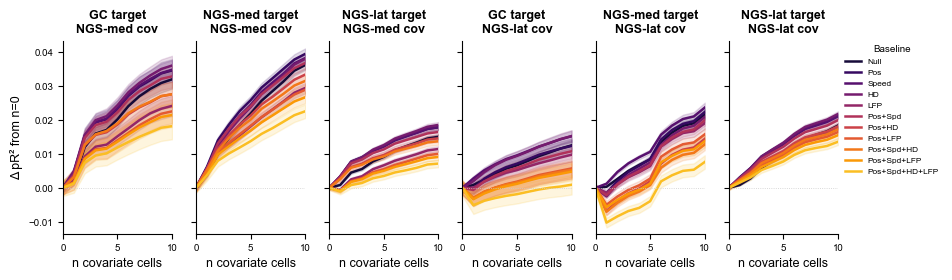

Saved: Figure4_medlat_OF.pdf


In [210]:
# ── Open Field: medial vs lateral NGS ────────────────────────────────────────
# Run the exploration cell above first to confirm COV_REGION_COL, TGT_REGION_COL,
# MEDIAL_VAL and LATERAL_VAL match the actual column names in data_ml_of.

_make_figure_medlat(
    data           = data_ml_of,
    baseline_order = OF_BASELINE_ORDER,
    baseline_label = OF_BASELINE_LABEL,
    title_prefix   = 'OF',
    save_name      = 'Figure4_medlat_OF.pdf',
)

Active combinations (6): ['GC target\nNGS-med cov', 'NGS-med target\nNGS-med cov', 'NGS-lat target\nNGS-med cov', 'GC target\nNGS-lat cov', 'NGS-med target\nNGS-lat cov', 'NGS-lat target\nNGS-lat cov']


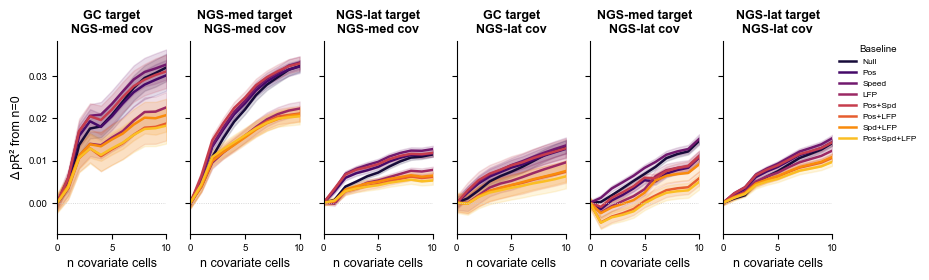

Saved: Figure4_medlat_VR.pdf


In [211]:
# ── Virtual Reality: medial vs lateral NGS ───────────────────────────────────
_make_figure_medlat(
    data           = data_ml_vr,
    baseline_order = VR_BASELINE_ORDER,
    baseline_label = VR_BASELINE_LABEL,
    title_prefix   = 'VR',
    save_name      = 'Figure4_medlat_VR.pdf',
)